# 🏠 HOME CREDIT DEFAULT RISK — ĐỒ ÁN MÔN HỌC MACHINE LEARNING


In [1]:
## BƯỚC 1: KẾT NỐI GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## BƯỚC 2: GIẢI NÉN DỮ LIỆU; Chỉ cần chạy 1 lần duy nhất. Những lần sau bỏ qua cell này.

import zipfile

zip_path = '/content/drive/MyDrive/!!!HỌC ĐH AI - MÁY HỌC/home-credit-default-risk.zip'
extract_path = '/content/drive/MyDrive/!!!HỌC ĐH AI - MÁY HỌC/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
    print("Các file đã giải nén:")
    print(z.namelist())

In [2]:
## BƯỚC 3: LOAD DỮ LIỆU

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/!!!HỌC ĐH AI - MÁY HỌC/application_train.csv')

# Xóa cột index thừa nếu có
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'Shape sau khi fix: {df.shape}')
print(f'Số cột: {df.shape[1]}')
print(f'Cột TARGET có không: {"TARGET" in df.columns}')
print(f'Phân phối TARGET:\n{df["TARGET"].value_counts()}')

Shape sau khi fix: (246009, 122)
Số cột: 122
Cột TARGET có không: True
Phân phối TARGET:
TARGET
0    226133
1     19876
Name: count, dtype: int64


In [3]:
## BƯỚC 4: SETUP THƯ VIỆN VÀ CẤU HÌNH

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Tạo thư mục lưu biểu đồ trên Drive
save_path = '/content/drive/MyDrive/!!!HỌC ĐH AI - MÁY HỌC/bieu_do/'
os.makedirs(save_path, exist_ok=True)

# Style cho biểu đồ đẹp hơn
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12

print("Setup hoàn tất!")
print(f"Biểu đồ sẽ được lưu tại: {save_path}")

Setup hoàn tất!
Biểu đồ sẽ được lưu tại: /content/drive/MyDrive/!!!HỌC ĐH AI - MÁY HỌC/bieu_do/


---
# PHẦN 3: PHÂN TÍCH DỮ LIỆU (EDA)

In [4]:
## 3.1 Tổng quan bộ dữ liệu

print("=" * 50)
print("TỔNG QUAN BỘ DỮ LIỆU")
print("=" * 50)
print(f"Số dòng (mẫu)     : {df.shape[0]:,}")
print(f"Số cột (features) : {df.shape[1]}")
print(f"\nSố features số    : {df.select_dtypes(include='number').shape[1]}")
print(f"Số features chữ   : {df.select_dtypes(include='object').shape[1]}")

print("\n" + "=" * 50)
print("PHÂN PHỐI NHÃN TARGET")
print("=" * 50)
counts = df['TARGET'].value_counts()
pcts   = df['TARGET'].value_counts(normalize=True) * 100
print(f"TARGET = 0 (trả đúng hạn)  : {counts[0]:,} mẫu ({pcts[0]:.1f}%)")
print(f"TARGET = 1 (khó khăn trả nợ): {counts[1]:,} mẫu ({pcts[1]:.1f}%)")

print("\n" + "=" * 50)
print("THỐNG KÊ DỮ LIỆU THIẾU (Top 10 cột)")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Số giá trị thiếu': missing,
    'Tỉ lệ (%)': missing_pct
}).query('`Số giá trị thiếu` > 0').sort_values('Tỉ lệ (%)', ascending=False)
print(missing_df.head(10).to_string())
print(f"\nTổng số cột có dữ liệu thiếu: {len(missing_df)}")

TỔNG QUAN BỘ DỮ LIỆU
Số dòng (mẫu)     : 246,009
Số cột (features) : 122

Số features số    : 106
Số features chữ   : 16

PHÂN PHỐI NHÃN TARGET
TARGET = 0 (trả đúng hạn)  : 226,133 mẫu (91.9%)
TARGET = 1 (khó khăn trả nợ): 19,876 mẫu (8.1%)

THỐNG KÊ DỮ LIỆU THIẾU (Top 10 cột)
                          Số giá trị thiếu  Tỉ lệ (%)
COMMONAREA_MEDI                     171930       69.9
COMMONAREA_MODE                     171930       69.9
COMMONAREA_AVG                      171930       69.9
NONLIVINGAPARTMENTS_MODE            170869       69.5
NONLIVINGAPARTMENTS_MEDI            170869       69.5
NONLIVINGAPARTMENTS_AVG             170869       69.5
LIVINGAPARTMENTS_AVG                168197       68.4
LIVINGAPARTMENTS_MEDI               168197       68.4
FONDKAPREMONT_MODE                  168287       68.4
LIVINGAPARTMENTS_MODE               168197       68.4

Tổng số cột có dữ liệu thiếu: 67


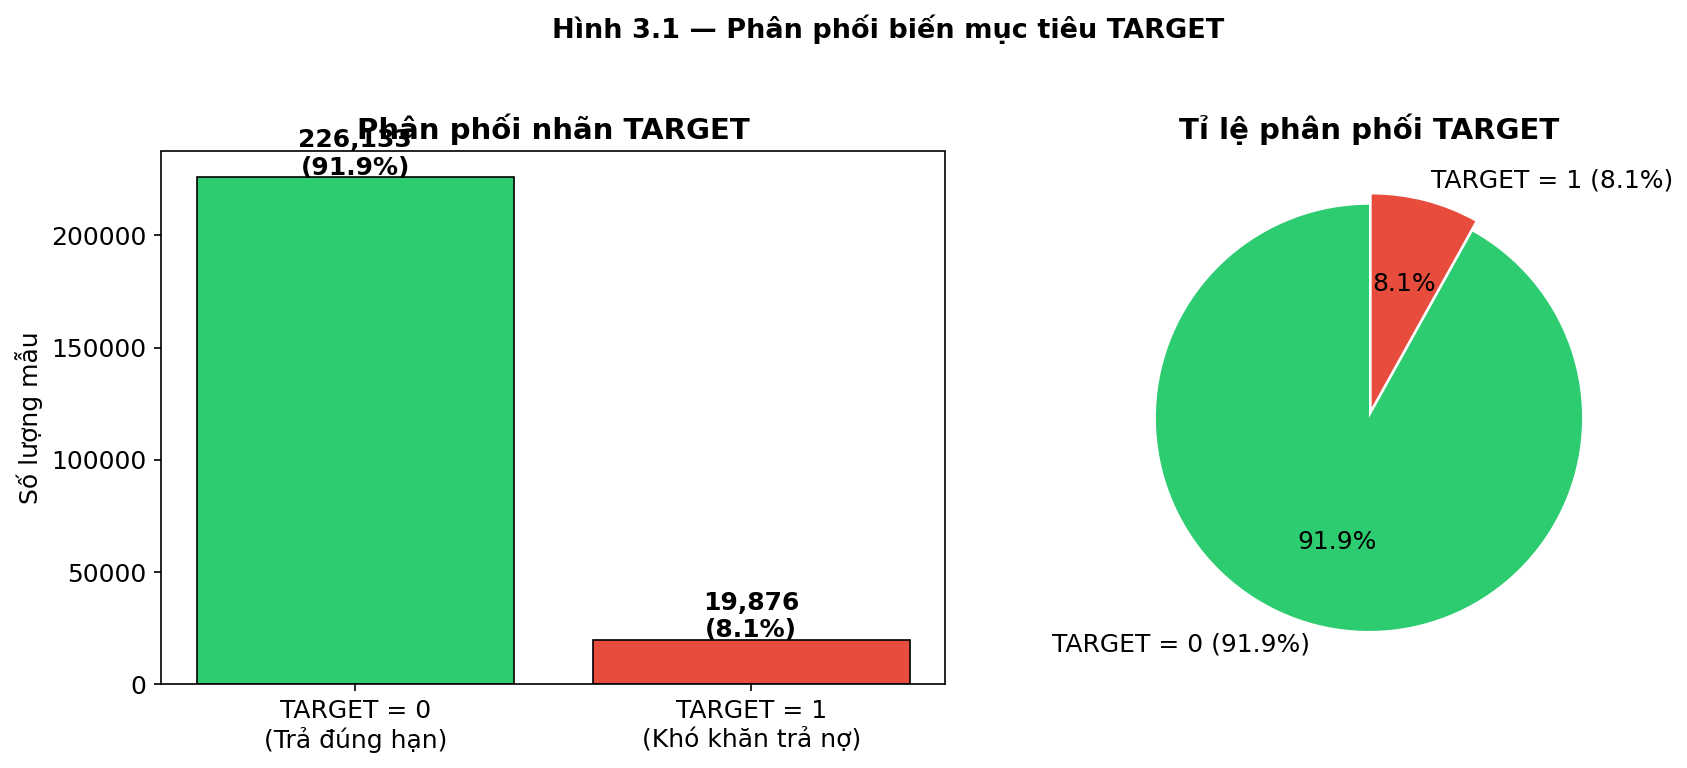

Đã lưu: H3.1_phan_phoi_target.png


In [5]:
## 3.2 Phân tích biến mục tiêu TARGET

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột
counts = df['TARGET'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['TARGET = 0\n(Trả đúng hạn)', 'TARGET = 1\n(Khó khăn trả nợ)'],
            counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Phân phối nhãn TARGET', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                ha='center', fontweight='bold')

# Biểu đồ tròn
axes[1].pie(counts.values,
            labels=['TARGET = 0 (91.9%)', 'TARGET = 1 (8.1%)'],
            colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Tỉ lệ phân phối TARGET', fontsize=14, fontweight='bold')

plt.suptitle('Hình 3.1 — Phân phối biến mục tiêu TARGET',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + 'H3.1_phan_phoi_target.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Đã lưu: H3.1_phan_phoi_target.png")

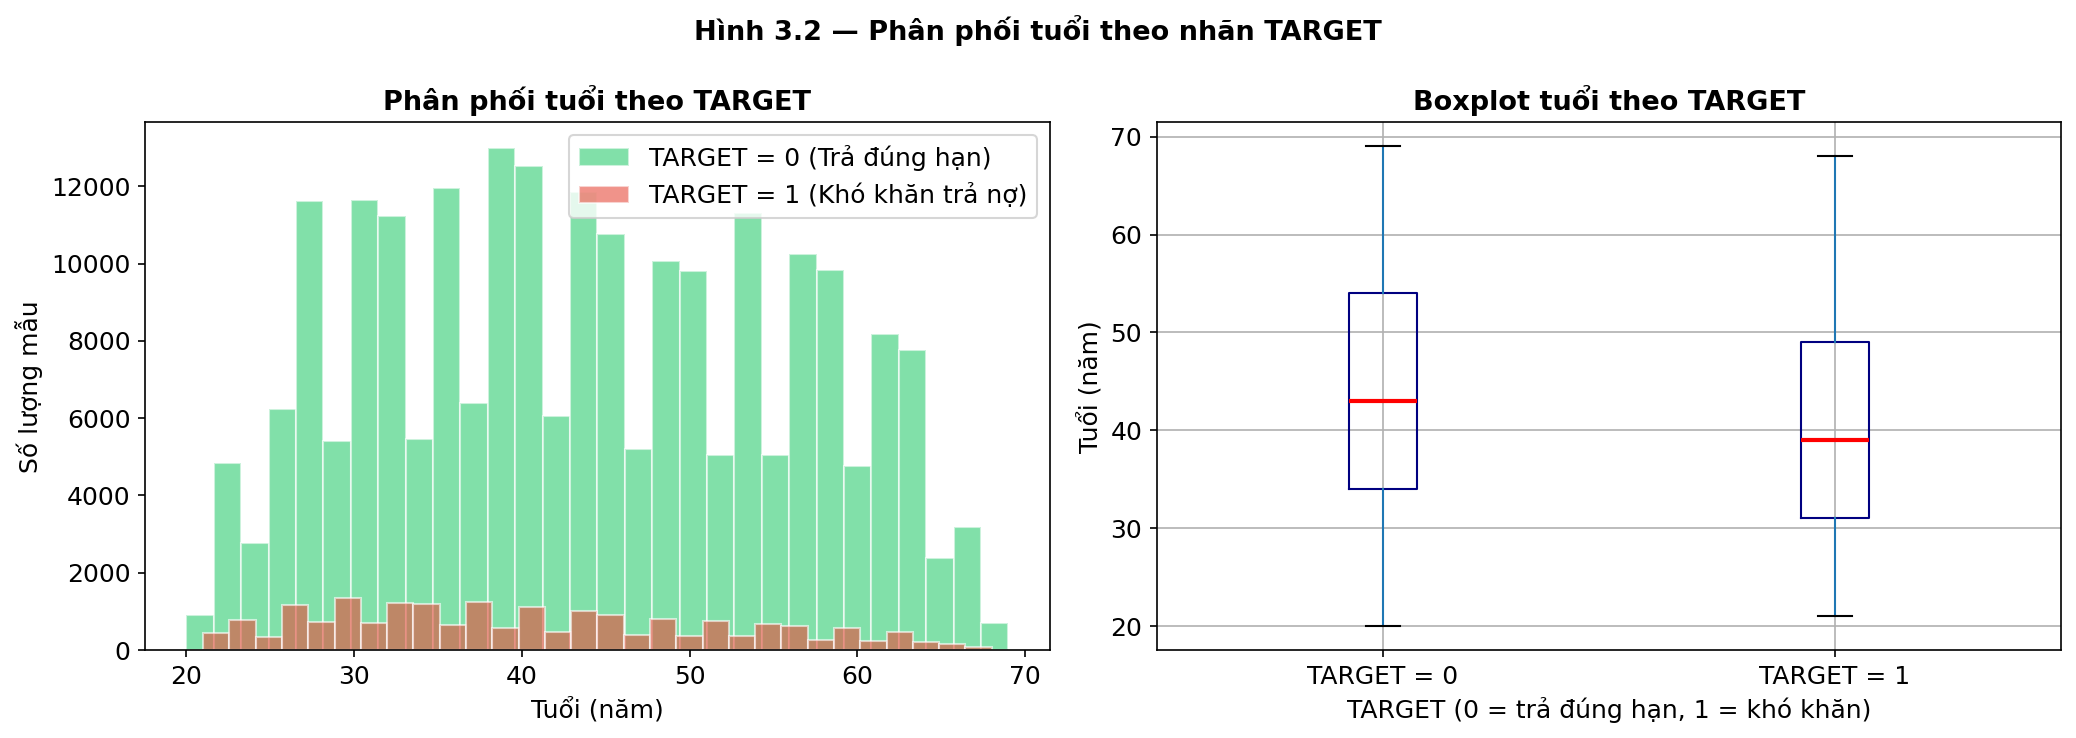

Tuổi trung bình theo TARGET:
TARGET
0    43.7
1    40.3

Nhận xét: Người trẻ tuổi hơn có xu hướng vỡ nợ cao hơn?
Tuổi TB TARGET=0: 43.7
Tuổi TB TARGET=1: 40.3


In [6]:
## 3.3 Phân tích đặc trưng tuổi tác

# Chuyển DAYS_BIRTH sang tuổi (năm)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram tuổi theo TARGET
for target, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'],
                                 ['TARGET = 0 (Trả đúng hạn)',
                                  'TARGET = 1 (Khó khăn trả nợ)']):
    axes[0].hist(df[df['TARGET'] == target]['AGE_YEARS'],
                 bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Phân phối tuổi theo TARGET', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tuổi (năm)')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].legend()

# Boxplot tuổi theo TARGET
df.boxplot(column='AGE_YEARS', by='TARGET', ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot tuổi theo TARGET', fontsize=13, fontweight='bold')
axes[1].set_xlabel('TARGET (0 = trả đúng hạn, 1 = khó khăn)')
axes[1].set_ylabel('Tuổi (năm)')
axes[1].set_xticklabels(['TARGET = 0', 'TARGET = 1'])
plt.suptitle('')

fig.suptitle('Hình 3.2 — Phân phối tuổi theo nhãn TARGET',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + 'H3.2_tuoi_theo_target.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Thống kê
print("Tuổi trung bình theo TARGET:")
print(df.groupby('TARGET')['AGE_YEARS'].mean().round(1).to_string())
print("\nNhận xét: Người trẻ tuổi hơn có xu hướng vỡ nợ cao hơn?")
print(f"Tuổi TB TARGET=0: {df[df['TARGET']==0]['AGE_YEARS'].mean():.1f}")
print(f"Tuổi TB TARGET=1: {df[df['TARGET']==1]['AGE_YEARS'].mean():.1f}")

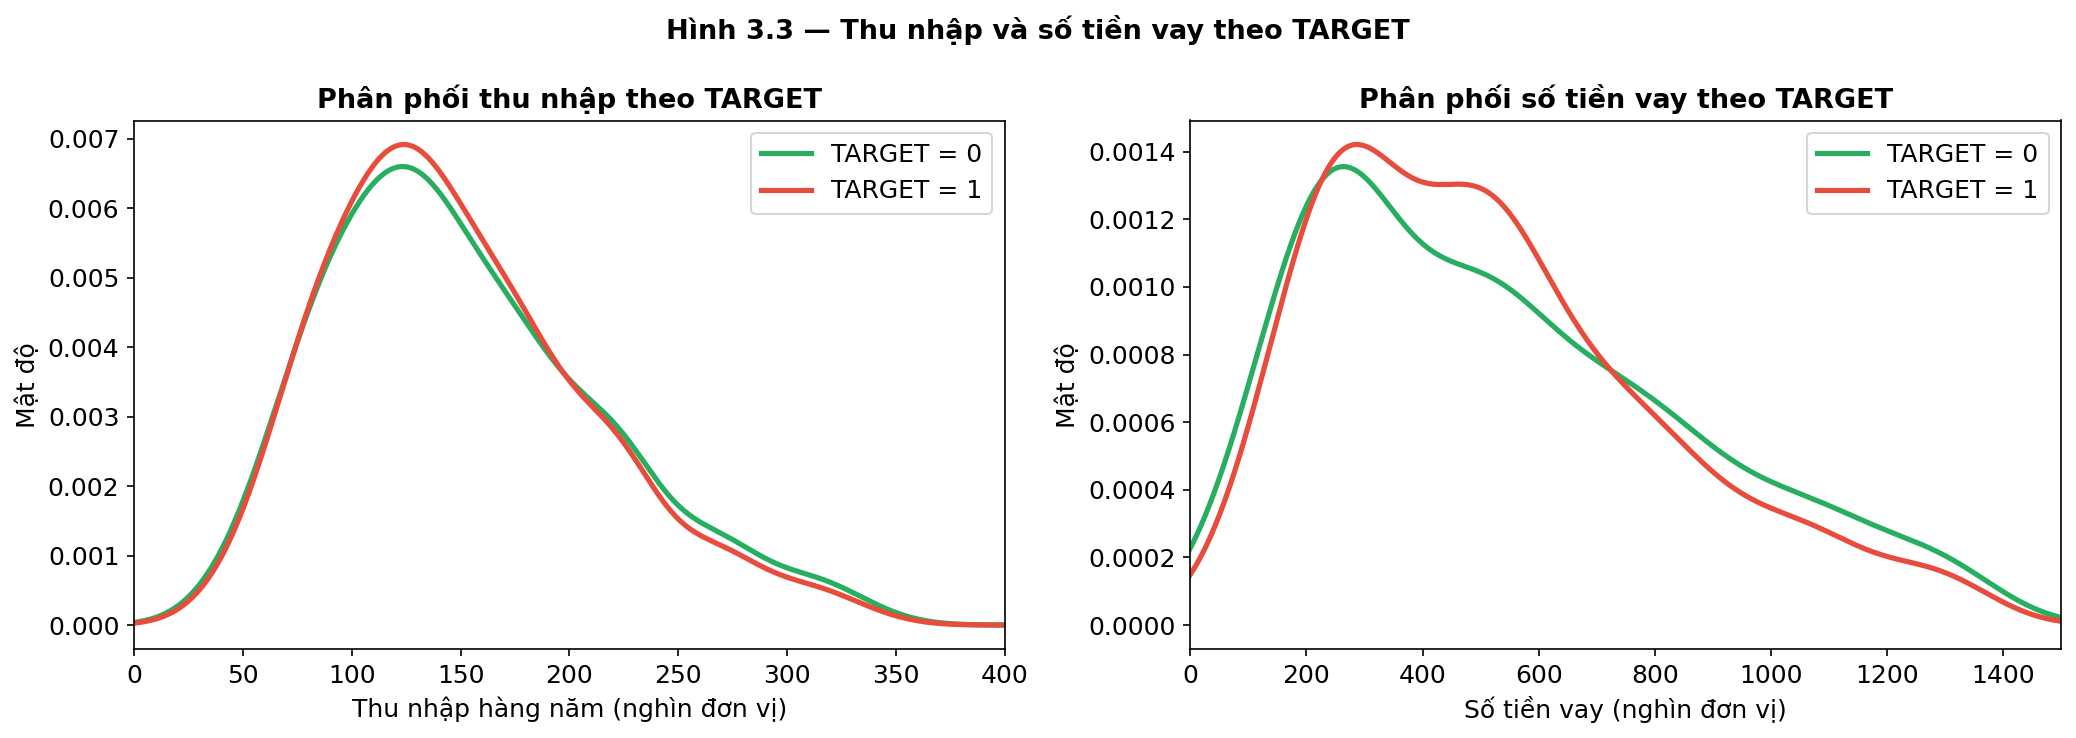

Đã lưu H3.3 mới!


In [7]:
## 3.4 Phân tích thu nhập và số tiền vay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_cap = df['AMT_INCOME_TOTAL'].quantile(0.95)
credit_cap = df['AMT_CREDIT'].quantile(0.95)
df_plot = df[(df['AMT_INCOME_TOTAL'] <= income_cap) &
             (df['AMT_CREDIT'] <= credit_cap)]

# Tăng bw_adjust để làm mượt đường KDE
for target, color, label in zip([0, 1], ['#27ae60', '#e74c3c'],
                                 ['TARGET = 0', 'TARGET = 1']):
    df_plot[df_plot['TARGET']==target]['AMT_INCOME_TOTAL'].divide(1000).plot(
        kind='density', ax=axes[0], color=color, label=label,
        linewidth=2.5, bw_method=0.3)

axes[0].set_title('Phân phối thu nhập theo TARGET', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Thu nhập hàng năm (nghìn đơn vị)')
axes[0].set_ylabel('Mật độ')
axes[0].legend()
axes[0].set_xlim(0, 400)

for target, color, label in zip([0, 1], ['#27ae60', '#e74c3c'],
                                 ['TARGET = 0', 'TARGET = 1']):
    df_plot[df_plot['TARGET']==target]['AMT_CREDIT'].divide(1000).plot(
        kind='density', ax=axes[1], color=color, label=label,
        linewidth=2.5, bw_method=0.3)

axes[1].set_title('Phân phối số tiền vay theo TARGET', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số tiền vay (nghìn đơn vị)')
axes[1].set_ylabel('Mật độ')
axes[1].legend()
axes[1].set_xlim(0, 1500)

fig.suptitle('Hình 3.3 — Thu nhập và số tiền vay theo TARGET',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + 'H3.3_thunhap_sotienva_target.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Đã lưu H3.3 mới!")

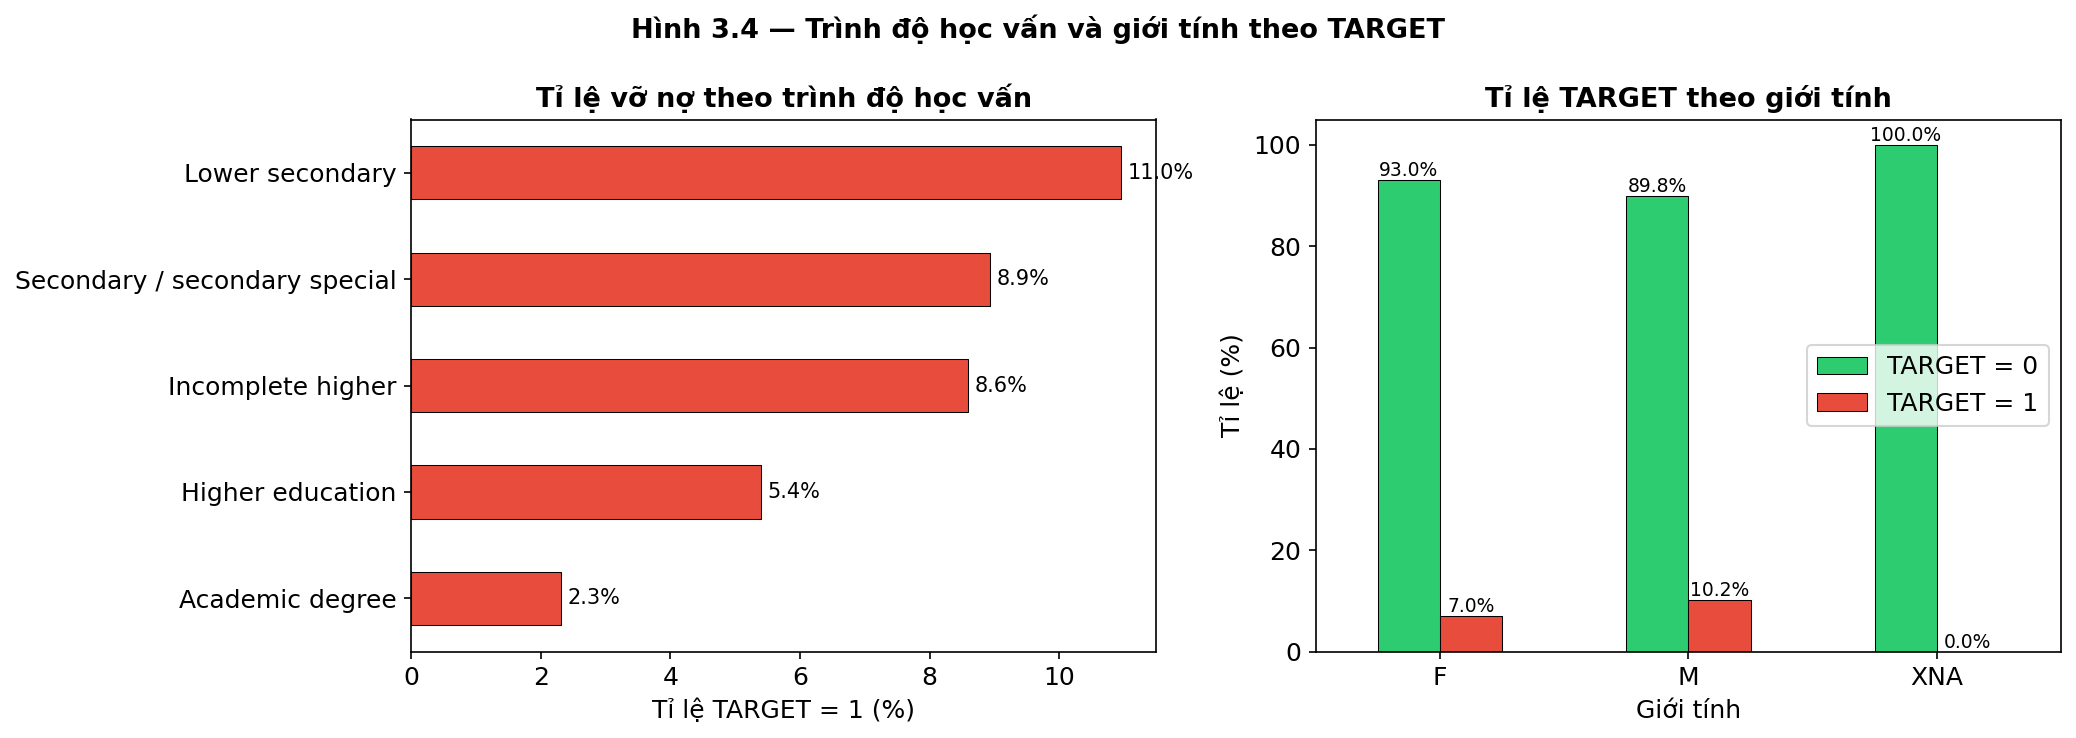

Tỉ lệ vỡ nợ theo giới tính:
TARGET           0     1
CODE_GENDER             
F             93.0   7.0
M             89.8  10.2
XNA          100.0   NaN


In [8]:
## 3.5 Phân tích trình độ học vấn và giới tính

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trình độ học vấn theo TARGET
edu_target = df.groupby(['NAME_EDUCATION_TYPE', 'TARGET']).size().unstack()
edu_pct = edu_target.div(edu_target.sum(axis=1), axis=0) * 100
edu_pct[1].sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Tỉ lệ vỡ nợ theo trình độ học vấn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tỉ lệ TARGET = 1 (%)')
axes[0].set_ylabel('')
for i, v in enumerate(edu_pct[1].sort_values(ascending=True)):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)

# Giới tính theo TARGET
gender_target = df.groupby(['CODE_GENDER', 'TARGET']).size().unstack()
gender_pct = gender_target.div(gender_target.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[1],
                color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.5, rot=0)
axes[1].set_title('Tỉ lệ TARGET theo giới tính', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Tỉ lệ (%)')
axes[1].legend(['TARGET = 0', 'TARGET = 1'])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

fig.suptitle('Hình 3.4 — Trình độ học vấn và giới tính theo TARGET',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + 'H3.4_hocvan_gioitinh_target.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("Tỉ lệ vỡ nợ theo giới tính:")
print(gender_pct.round(1).to_string())

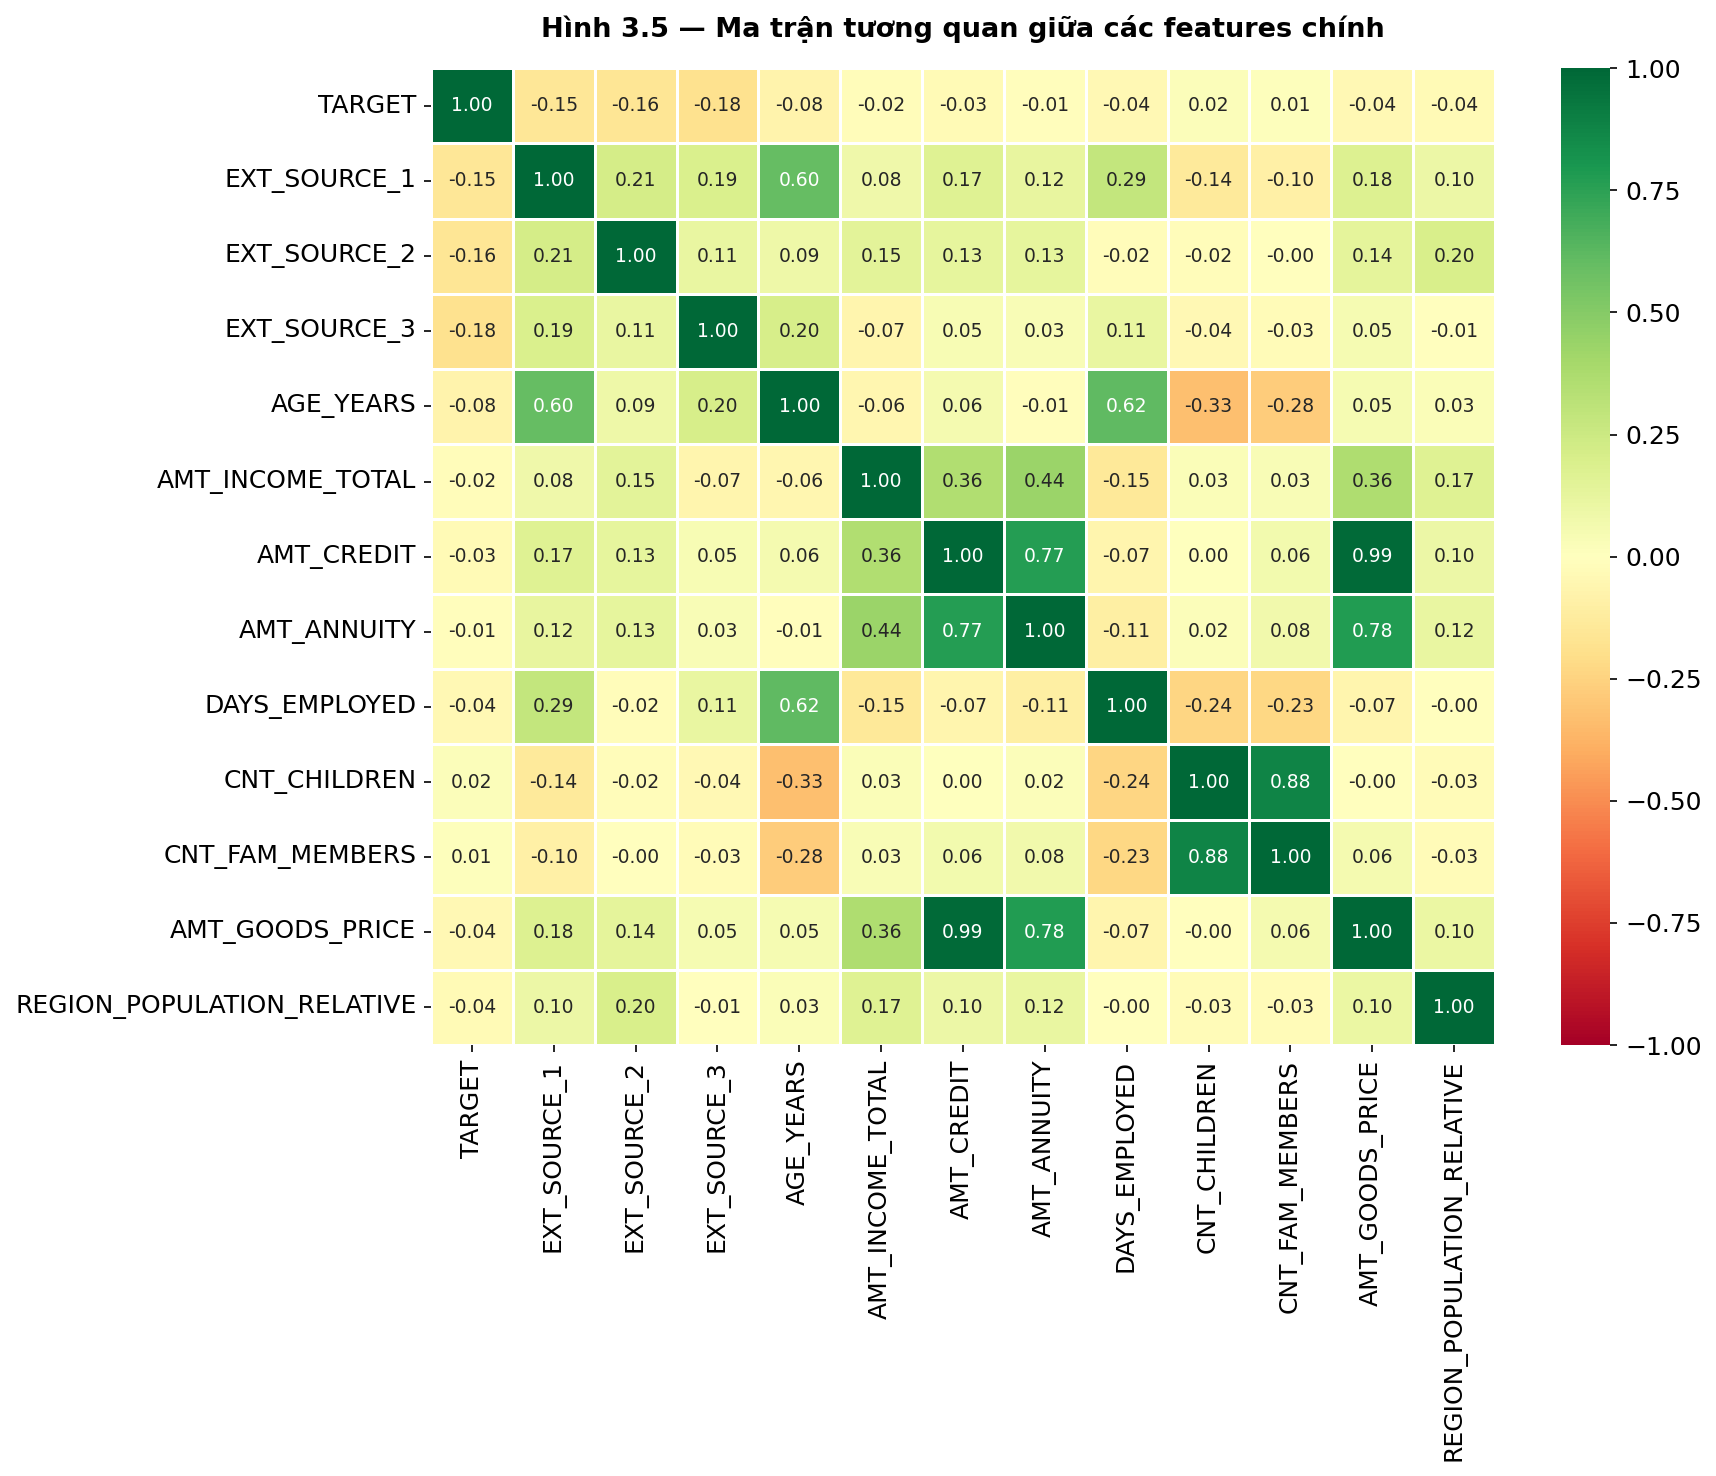

Top features tương quan với TARGET:
EXT_SOURCE_3                 -0.180096
EXT_SOURCE_2                 -0.158824
EXT_SOURCE_1                 -0.154135
AGE_YEARS                    -0.077650
DAYS_EMPLOYED                -0.044639
AMT_GOODS_PRICE              -0.040660
REGION_POPULATION_RELATIVE   -0.036908
AMT_CREDIT                   -0.031533
AMT_INCOME_TOTAL             -0.020385
AMT_ANNUITY                  -0.012582
CNT_FAM_MEMBERS               0.009802
CNT_CHILDREN                  0.019643


In [9]:
## 3.6 Phân tích tương quan giữa các đặc trưng

fig, ax = plt.subplots(figsize=(12, 10))

# Chọn các features số quan trọng nhất
key_features = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AGE_YEARS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE'
]

corr = df[key_features].corr()

mask = corr.isnull()
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            mask=mask,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Hình 3.5 — Ma trận tương quan giữa các features chính',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(save_path + 'H3.5_heatmap_tuong_quan.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Top features tương quan với TARGET
print("Top features tương quan với TARGET:")
print(corr['TARGET'].drop('TARGET').sort_values().to_string())

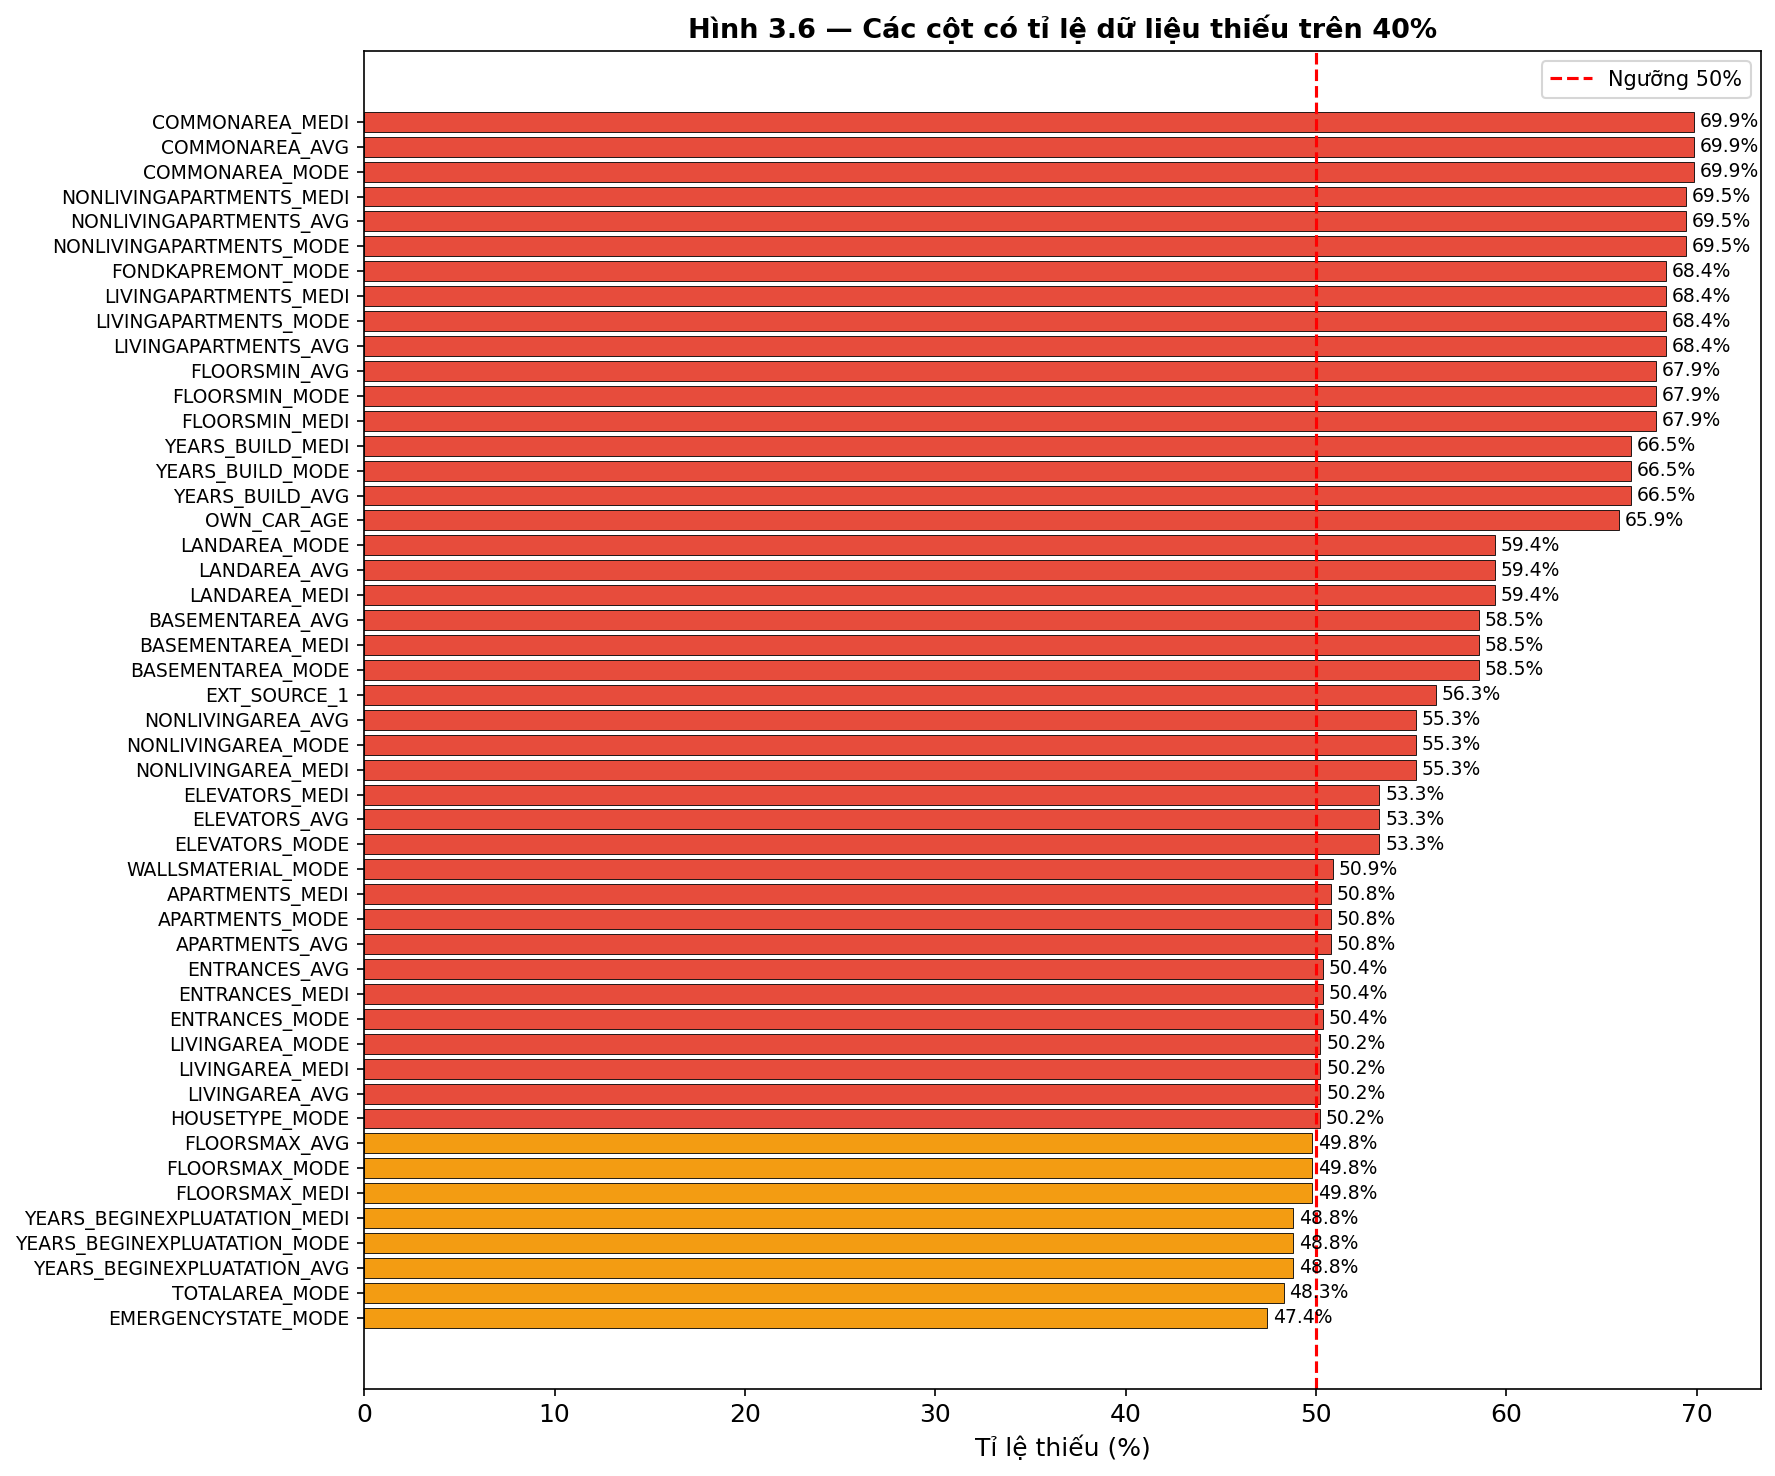

Số cột missing > 50%: 41
Số cột missing > 40%: 49
Số cột missing > 10%: 57


In [10]:
## 3.7 Phân tích dữ liệu thiếu (Missing Values)

fig, ax = plt.subplots(figsize=(12, 10))

# Chỉ lấy cột missing > 40% để biểu đồ thoáng hơn
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_high = missing_pct[missing_pct > 40].sort_values(ascending=True)

colors = ['#e74c3c' if x > 50 else '#f39c12'
          for x in missing_high.values]

bars = ax.barh(range(len(missing_high)), missing_high.values,
               color=colors, edgecolor='black', linewidth=0.4)

ax.set_yticks(range(len(missing_high)))
ax.set_yticklabels(missing_high.index, fontsize=9)
ax.set_title('Hình 3.6 — Các cột có tỉ lệ dữ liệu thiếu trên 40%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tỉ lệ thiếu (%)')
ax.axvline(x=50, color='red', linestyle='--',
           linewidth=1.5, label='Ngưỡng 50%')
ax.legend(fontsize=10)

for i, v in enumerate(missing_high.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(save_path + 'H3.6_missing_values.png',
            bbox_inches='tight', dpi=150)
plt.show()

print(f"Số cột missing > 50%: {(missing_pct > 50).sum()}")
print(f"Số cột missing > 40%: {(missing_pct > 40).sum()}")
print(f"Số cột missing > 10%: {(missing_pct > 10).sum()}")

---
# PHẦN 4: TIỀN XỬ LÝ DỮ LIỆU

Gồm 4 bước:
- **Bước 1:** Xử lý missing values
- **Bước 2:** Encoding categorical features
- **Bước 3:** Feature engineering
- **Bước 4:** Scaling + Train/Val split + Xử lý imbalanced class

In [11]:
## PHẦN 4 — BƯỚC 1: XỬ LÝ MISSING VALUES

import numpy as np

# Tách features và target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Tách features số và phân loại
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Số features số   : {len(num_cols)}")
print(f"Số features chữ  : {len(cat_cols)}")

# Xóa các cột số có missing > 60%
missing_pct = X[num_cols].isnull().sum() / len(X) * 100
cols_to_drop = missing_pct[missing_pct > 60].index.tolist()
X = X.drop(columns=cols_to_drop)
num_cols = [c for c in num_cols if c not in cols_to_drop]

print(f"\nĐã xóa {len(cols_to_drop)} cột số có missing > 60%")
print(f"Số features số còn lại: {len(num_cols)}")

# Điền median cho features số còn thiếu
for col in num_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

# Điền mode cho features phân loại
for col in cat_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mode()[0])

print(f"\nSau xử lý missing:")
print(f"Tổng missing còn lại: {X.isnull().sum().sum()}")

Số features số   : 105
Số features chữ  : 16

Đã xóa 16 cột số có missing > 60%
Số features số còn lại: 89

Sau xử lý missing:
Tổng missing còn lại: 0


In [12]:
## PHẦN 4 — BƯỚC 2: ENCODING CATEGORICAL FEATURES

from sklearn.preprocessing import LabelEncoder

# Kiểm tra số giá trị unique của từng cột phân loại
print("Số giá trị unique của từng cột phân loại:")
for col in cat_cols:
    print(f"  {col:<40} {X[col].nunique()} giá trị")

# Cột chỉ có 2 giá trị → Label Encoding
binary_cols = [col for col in cat_cols if X[col].nunique() == 2]
# Cột có nhiều hơn 2 giá trị → One-Hot Encoding
multi_cols  = [col for col in cat_cols if X[col].nunique() > 2]

print(f"\nLabel Encoding ({len(binary_cols)} cột): {binary_cols}")
print(f"One-Hot Encoding ({len(multi_cols)} cột): {multi_cols}")

# Label Encoding
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# One-Hot Encoding
X = pd.get_dummies(X, columns=multi_cols, drop_first=False)

print(f"\nSau encoding:")
print(f"Shape X: {X.shape}")
print(f"Không còn cột chữ: {X.select_dtypes(include='object').shape[1] == 0}")

Số giá trị unique của từng cột phân loại:
  NAME_CONTRACT_TYPE                       2 giá trị
  CODE_GENDER                              3 giá trị
  FLAG_OWN_CAR                             2 giá trị
  FLAG_OWN_REALTY                          2 giá trị
  NAME_TYPE_SUITE                          7 giá trị
  NAME_INCOME_TYPE                         8 giá trị
  NAME_EDUCATION_TYPE                      5 giá trị
  NAME_FAMILY_STATUS                       6 giá trị
  NAME_HOUSING_TYPE                        6 giá trị
  OCCUPATION_TYPE                          18 giá trị
  WEEKDAY_APPR_PROCESS_START               7 giá trị
  ORGANIZATION_TYPE                        58 giá trị
  FONDKAPREMONT_MODE                       4 giá trị
  HOUSETYPE_MODE                           3 giá trị
  WALLSMATERIAL_MODE                       7 giá trị
  EMERGENCYSTATE_MODE                      2 giá trị

Label Encoding (4 cột): ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']
On

In [13]:
## PHẦN 4 — BƯỚC 3: FEATURE ENGINEERING

# Tạo thêm features mới có ý nghĩa từ features hiện có
X['CREDIT_INCOME_RATIO']    = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + 1)
X['ANNUITY_INCOME_RATIO']   = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + 1)
X['CREDIT_TERM']            = X['AMT_ANNUITY'] / (X['AMT_CREDIT'] + 1)
X['INCOME_PER_PERSON']      = X['AMT_INCOME_TOTAL'] / (X['CNT_FAM_MEMBERS'] + 1)
X['EMPLOYED_TO_AGE_RATIO']  = X['DAYS_EMPLOYED'] / (X['DAYS_BIRTH'] + 1)

print("Đã tạo 5 features mới:")
print("  CREDIT_INCOME_RATIO   — Tỉ lệ tiền vay / thu nhập")
print("  ANNUITY_INCOME_RATIO  — Tỉ lệ trả góp / thu nhập")
print("  CREDIT_TERM           — Kỳ hạn vay ước tính")
print("  INCOME_PER_PERSON     — Thu nhập bình quân đầu người trong gia đình")
print("  EMPLOYED_TO_AGE_RATIO — Tỉ lệ thâm niên / tuổi")

print(f"\nShape X sau feature engineering: {X.shape}")

Đã tạo 5 features mới:
  CREDIT_INCOME_RATIO   — Tỉ lệ tiền vay / thu nhập
  ANNUITY_INCOME_RATIO  — Tỉ lệ trả góp / thu nhập
  CREDIT_TERM           — Kỳ hạn vay ước tính
  INCOME_PER_PERSON     — Thu nhập bình quân đầu người trong gia đình
  EMPLOYED_TO_AGE_RATIO — Tỉ lệ thâm niên / tuổi

Shape X sau feature engineering: (246009, 230)


In [14]:
## PHẦN 4 — BƯỚC 4: SCALING + TRAIN/VAL SPLIT + XỬ LÝ IMBALANCED CLASS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 4.1 Train/Validation split (80/20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("PHÂN CHIA TẬP DỮ LIỆU")
print("=" * 50)
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"\nTỉ lệ TARGET=1 trong train : {y_train.mean()*100:.1f}%")
print(f"Tỉ lệ TARGET=1 trong val   : {y_val.mean()*100:.1f}%")

# 4.2 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print("\n" + "=" * 50)
print("CHUẨN HÓA DỮ LIỆU (StandardScaler)")
print("=" * 50)
print("Fit trên tập train, transform cả train và val")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape  : {X_val_scaled.shape}")

# 4.3 Tính class weight để xử lý imbalanced
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("\n" + "=" * 50)
print("XỬ LÝ MẤT CÂN BẰNG LỚP (Class Weighting)")
print("=" * 50)
print(f"Class weight TARGET=0: {class_weights[0]:.4f}")
print(f"Class weight TARGET=1: {class_weights[1]:.4f}")
print(f"\nÝ nghĩa: Mô hình sẽ phạt nặng hơn {class_weights[1]/class_weights[0]:.1f}x")
print("khi dự đoán sai class 1 (vỡ nợ) so với class 0")

print("\n✅ Tiền xử lý hoàn tất!")
print(f"Sẵn sàng huấn luyện với {X_train_scaled.shape[0]:,} mẫu train")
print(f"                    và {X_val_scaled.shape[0]:,} mẫu validation")

PHÂN CHIA TẬP DỮ LIỆU
X_train: (196807, 230)
X_val  : (49202, 230)

Tỉ lệ TARGET=1 trong train : 8.1%
Tỉ lệ TARGET=1 trong val   : 8.1%

CHUẨN HÓA DỮ LIỆU (StandardScaler)
Fit trên tập train, transform cả train và val
X_train_scaled shape: (196807, 230)
X_val_scaled shape  : (49202, 230)

XỬ LÝ MẤT CÂN BẰNG LỚP (Class Weighting)
Class weight TARGET=0: 0.5439
Class weight TARGET=1: 6.1885

Ý nghĩa: Mô hình sẽ phạt nặng hơn 11.4x
khi dự đoán sai class 1 (vỡ nợ) so với class 0

✅ Tiền xử lý hoàn tất!
Sẵn sàng huấn luyện với 196,807 mẫu train
                    và 49,202 mẫu validation


---
# PHẦN 5: MÔ HÌNH VÀ THÔNG SỐ

In [15]:
## PHẦN 5 — HUẤN LUYỆN 4 MÔ HÌNH

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

trained_models = {}
training_times = {}

print("=" * 55)
print("BẮT ĐẦU HUẤN LUYỆN 4 MÔ HÌNH")
print("=" * 55)

for name, model in models.items():
    print(f"\n⏳ Đang huấn luyện: {name}...")
    start = time.time()

    if name in ['Logistic Regression']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    elapsed = time.time() - start
    trained_models[name] = model
    training_times[name] = elapsed
    print(f"✅ Hoàn tất: {elapsed:.1f} giây")

print("\n" + "=" * 55)
print("TỔNG KẾT THỜI GIAN HUẤN LUYỆN")
print("=" * 55)
for name, t in training_times.items():
    print(f"  {name:<25} {t:.1f} giây")

BẮT ĐẦU HUẤN LUYỆN 4 MÔ HÌNH

⏳ Đang huấn luyện: Logistic Regression...
✅ Hoàn tất: 32.8 giây

⏳ Đang huấn luyện: Decision Tree...
✅ Hoàn tất: 10.9 giây

⏳ Đang huấn luyện: Random Forest...
✅ Hoàn tất: 38.7 giây

⏳ Đang huấn luyện: LightGBM...


LightGBMError: Do not support special JSON characters in feature name.

In [16]:
## FIX: Đổi tên cột đặc biệt cho LightGBM

import re

# Làm sạch tên cột — xóa ký tự đặc biệt
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()

X_train_clean.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col)
                          for col in X_train_clean.columns]
X_val_clean.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col)
                        for col in X_val_clean.columns]

print("Đã làm sạch tên cột!")
print(f"Số cột: {X_train_clean.shape[1]}")
print(f"Kiểm tra ký tự đặc biệt còn không: "
      f"{any('[' in c or ',' in c for c in X_train_clean.columns)}")

# Train lại LightGBM với cột đã làm sạch
import time
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("\n⏳ Đang huấn luyện LightGBM...")
start = time.time()
lgbm.fit(X_train_clean, y_train)
elapsed = time.time() - start
print(f"✅ Hoàn tất: {elapsed:.1f} giây")

# Thêm vào dict
trained_models['LightGBM'] = lgbm
training_times['LightGBM'] = elapsed

# Lưu lại để dùng về sau
X_train_lgbm = X_train_clean
X_val_lgbm = X_val_clean

print("\nTổng kết thời gian huấn luyện:")
for name, t in training_times.items():
    print(f"  {name:<25} {t:.1f} giây")

Đã làm sạch tên cột!
Số cột: 230
Kiểm tra ký tự đặc biệt còn không: False

⏳ Đang huấn luyện LightGBM...
✅ Hoàn tất: 32.8 giây

Tổng kết thời gian huấn luyện:
  Logistic Regression       32.8 giây
  Decision Tree             10.9 giây
  Random Forest             38.7 giây
  LightGBM                  32.8 giây


In [17]:
## PHẦN 6 — ĐÁNH GIÁ MÔ HÌNH

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import pandas as pd

results = {}

print("=" * 65)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION")
print("=" * 65)

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred  = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
    elif name == 'LightGBM':
        y_pred  = model.predict(X_val_lgbm)
        y_proba = model.predict_proba(X_val_lgbm)[:, 1]
    else:
        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall':    round(recall_score(y_val, y_pred), 4),
        'F1-Score':  round(f1_score(y_val, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_proba), 4),
    }

    print(f"\n{'─'*65}")
    print(f"  {name}")
    print(f"{'─'*65}")
    print(f"  Accuracy : {results[name]['Accuracy']:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall   : {results[name]['Recall']:.4f}")
    print(f"  F1-Score : {results[name]['F1-Score']:.4f}")
    print(f"  ROC-AUC  : {results[name]['ROC-AUC']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_val, y_pred,
          target_names=['TARGET=0', 'TARGET=1']))

# Bảng tổng hợp
print("\n" + "=" * 65)
print("BẢNG SO SÁNH TỔNG HỢP")
print("=" * 65)
df_results = pd.DataFrame(results).T
print(df_results.to_string())
print(f"\n→ Mô hình tốt nhất theo ROC-AUC: "
      f"{df_results['ROC-AUC'].idxmax()} "
      f"({df_results['ROC-AUC'].max():.4f})")

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION

─────────────────────────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────────────────────────
  Accuracy : 0.6885
  Precision: 0.1621
  Recall   : 0.6853
  F1-Score : 0.2622
  ROC-AUC  : 0.7519

  Classification Report:
              precision    recall  f1-score   support

    TARGET=0       0.96      0.69      0.80     45227
    TARGET=1       0.16      0.69      0.26      3975

    accuracy                           0.69     49202
   macro avg       0.56      0.69      0.53     49202
weighted avg       0.90      0.69      0.76     49202


─────────────────────────────────────────────────────────────────
  Decision Tree
─────────────────────────────────────────────────────────────────
  Accuracy : 0.6380
  Precision: 0.1417
  Recall   : 0.6886
  F1-Score : 0.2351
  ROC-AUC  : 0.7153

  Classification Report:
              precision    recall  f1-score   support

    TARGET=0       0.96  

In [18]:
print("\n" + "=" * 60)
print("BẢNG TÓM TẮT KẾT QUẢ 4 MÔ HÌNH")
print("=" * 60)
print(df_results.to_string())
print(f"\nMô hình tốt nhất ROC-AUC : {df_results['ROC-AUC'].idxmax()} ({df_results['ROC-AUC'].max():.4f})")
print(f"Mô hình tốt nhất F1-Score: {df_results['F1-Score'].idxmax()} ({df_results['F1-Score'].max():.4f})")
print(f"Mô hình tốt nhất Recall  : {df_results['Recall'].idxmax()} ({df_results['Recall'].max():.4f})")


BẢNG TÓM TẮT KẾT QUẢ 4 MÔ HÌNH
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6885     0.1621  0.6853    0.2622   0.7519
Decision Tree          0.6380     0.1417  0.6886    0.2351   0.7153
Random Forest          0.6957     0.1612  0.6581    0.2590   0.7387
LightGBM               0.7332     0.1819  0.6584    0.2850   0.7658

Mô hình tốt nhất ROC-AUC : LightGBM (0.7658)
Mô hình tốt nhất F1-Score: LightGBM (0.2850)
Mô hình tốt nhất Recall  : Decision Tree (0.6886)


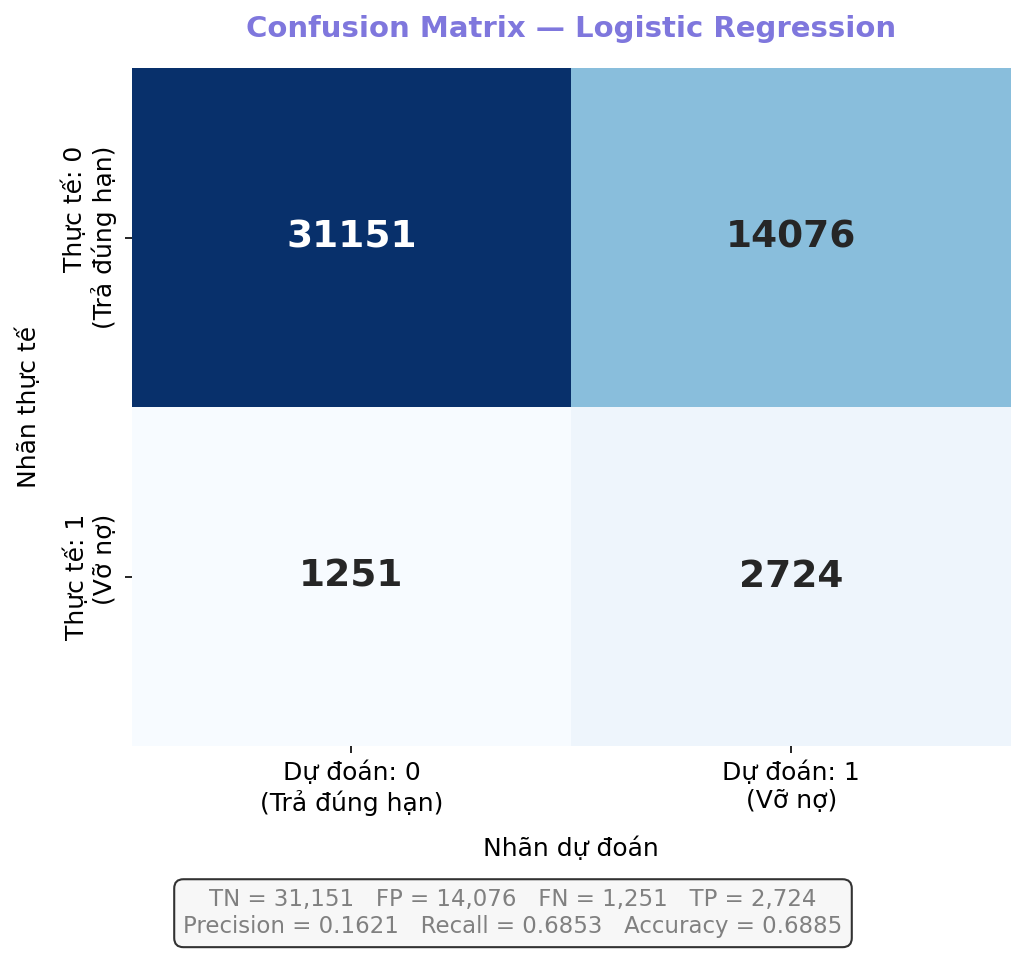

Đã lưu: H6.1a_cm_logistic.png


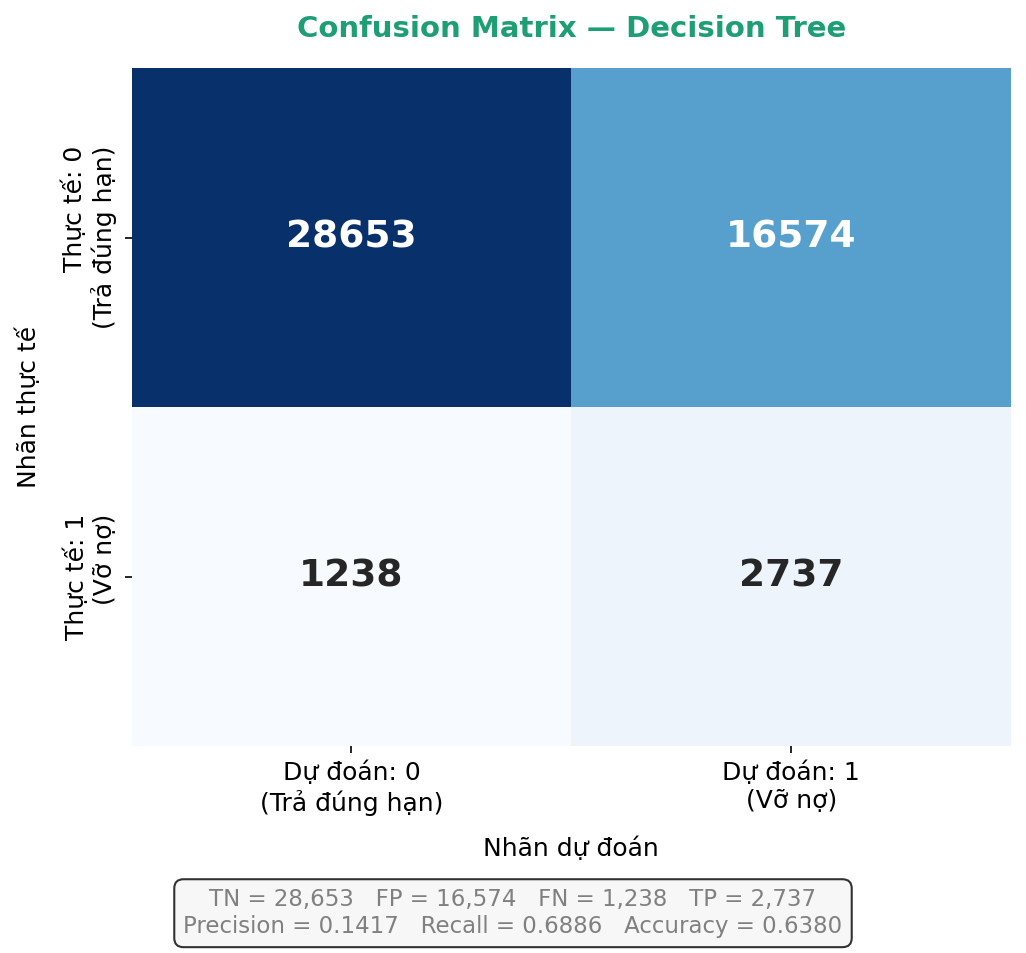

Đã lưu: H6.1b_cm_decision_tree.png


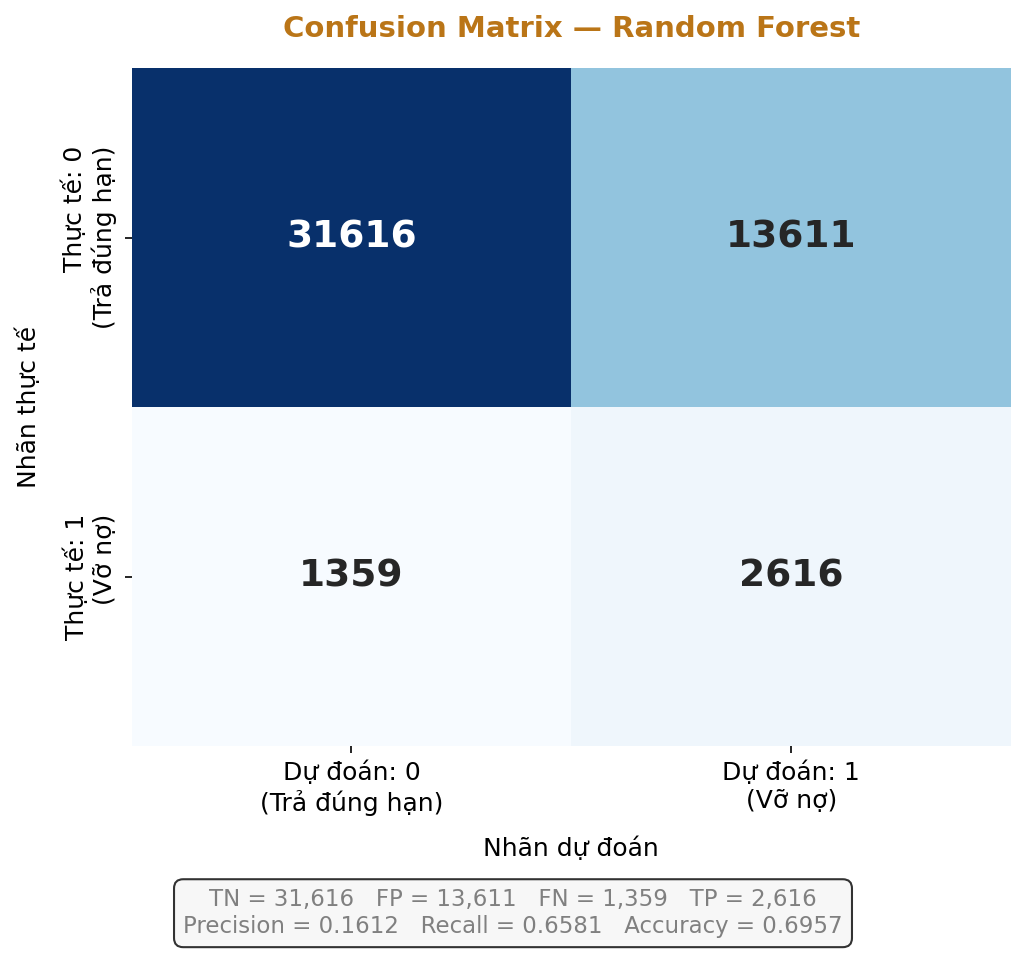

Đã lưu: H6.1c_cm_random_forest.png


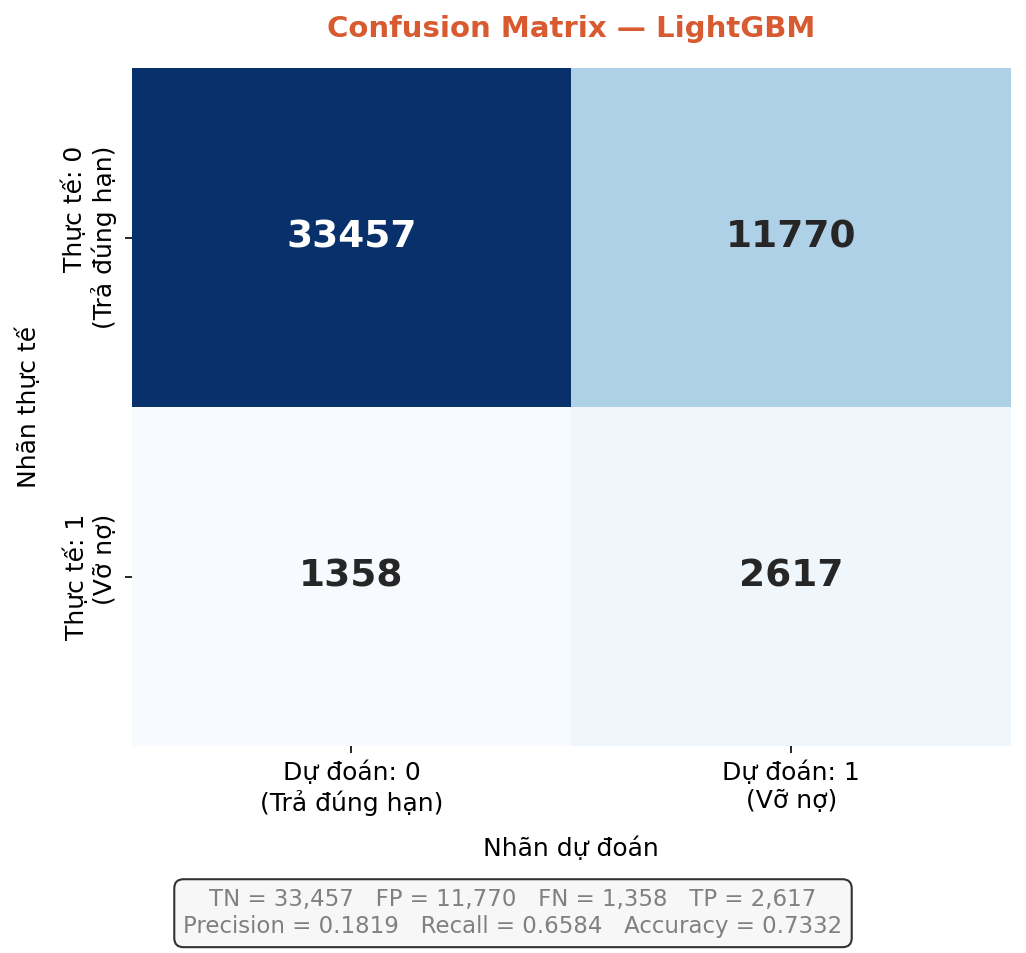

Đã lưu: H6.1d_cm_lightgbm.png


In [20]:
## PHẦN 6 — CONFUSION MATRIX (tách riêng 4 ảnh)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_colors = {
    'Logistic Regression': '#7F77DD',
    'Decision Tree':       '#1D9E75',
    'Random Forest':       '#BA7517',
    'LightGBM':            '#D85A30'
}

model_filenames = {
    'Logistic Regression': 'H6.1a_cm_logistic.png',
    'Decision Tree':       'H6.1b_cm_decision_tree.png',
    'Random Forest':       'H6.1c_cm_random_forest.png',
    'LightGBM':            'H6.1d_cm_lightgbm.png',
}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_val_scaled)
    elif name == 'LightGBM':
        y_pred = model.predict(X_val_lgbm)
    else:
        y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['Dự đoán: 0\n(Trả đúng hạn)',
                             'Dự đoán: 1\n(Vỡ nợ)'],
                yticklabels=['Thực tế: 0\n(Trả đúng hạn)',
                             'Thực tế: 1\n(Vỡ nợ)'],
                ax=ax, cbar=False,
                annot_kws={'size': 18, 'weight': 'bold'})

    ax.set_title(f'Confusion Matrix — {name}',
                 fontsize=14, fontweight='bold',
                 color=model_colors[name], pad=15)
    ax.set_xlabel('Nhãn dự đoán', fontsize=12, labelpad=10)
    ax.set_ylabel('Nhãn thực tế', fontsize=12, labelpad=10)

    # Thống kê chi tiết bên dưới
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    accuracy  = (tp + tn) / (tp + tn + fp + fn)

    stats = (f'TN = {tn:,}   FP = {fp:,}   FN = {fn:,}   TP = {tp:,}\n'
             f'Precision = {precision:.4f}   '
             f'Recall = {recall:.4f}   '
             f'Accuracy = {accuracy:.4f}')

    fig.text(0.5, -0.05, stats, ha='center',
             fontsize=11, color='gray',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='#f5f5f5', alpha=0.8))

    plt.tight_layout()
    fname = model_filenames[name]
    plt.savefig(save_path + fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Đã lưu: {fname}")

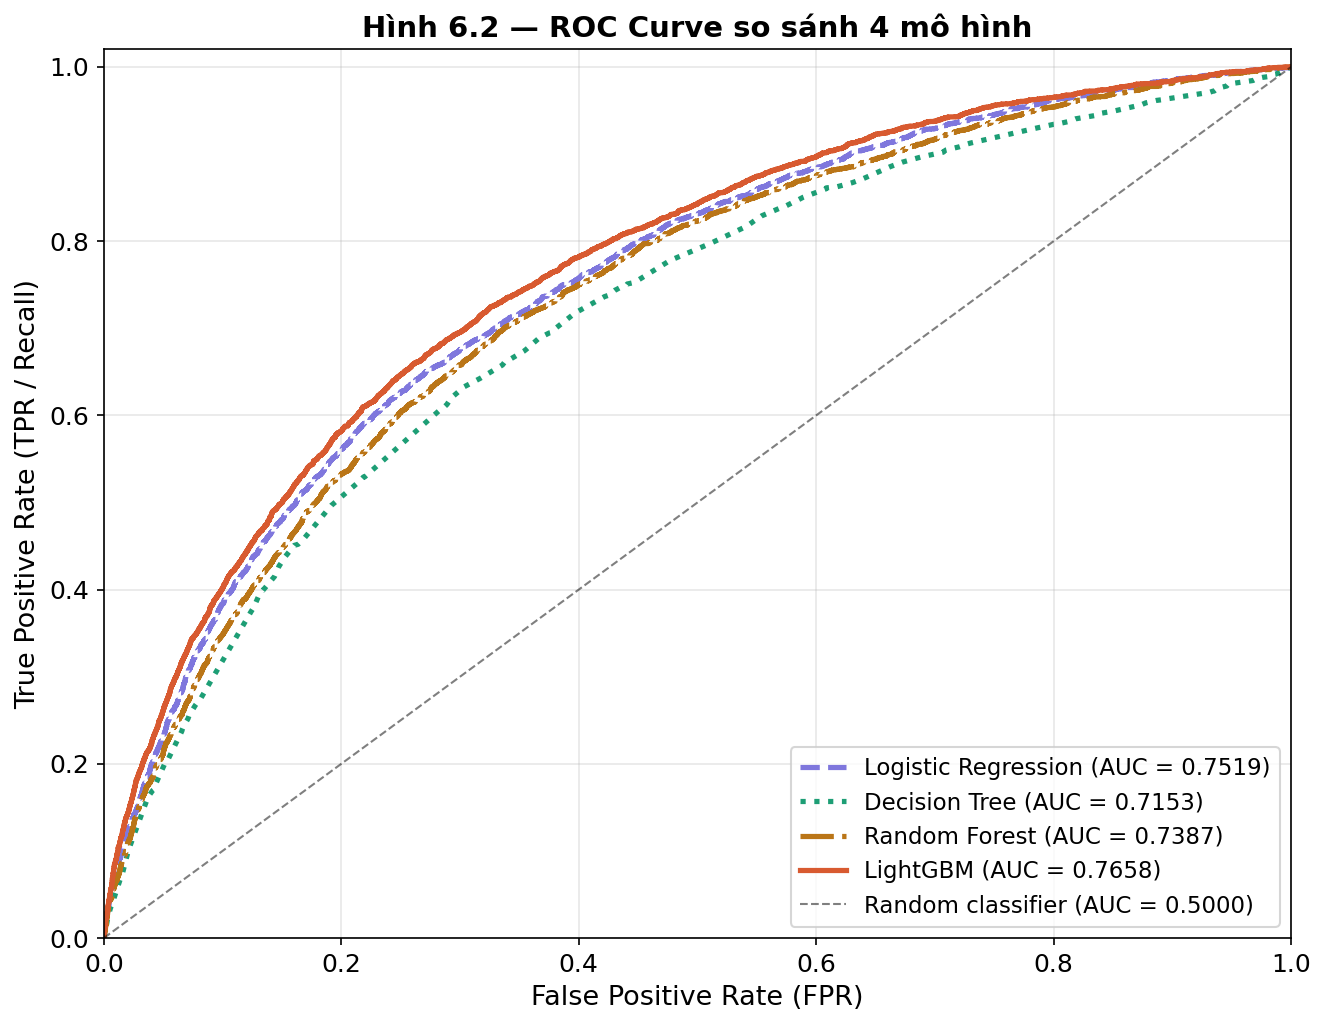

Đã lưu: H6.2_roc_curve.png


In [21]:
## PHẦN 6 — ROC CURVE SO SÁNH 4 MÔ HÌNH

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

model_colors = {
    'Logistic Regression': '#7F77DD',
    'Decision Tree':       '#1D9E75',
    'Random Forest':       '#BA7517',
    'LightGBM':            '#D85A30'
}

model_styles = {
    'Logistic Regression': '--',
    'Decision Tree':       ':',
    'Random Forest':       '-.',
    'LightGBM':            '-'
}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
    elif name == 'LightGBM':
        y_proba = model.predict_proba(X_val_lgbm)[:, 1]
    else:
        y_proba = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=model_colors[name],
            linestyle=model_styles[name],
            linewidth=2.5,
            label=f'{name} (AUC = {roc_auc:.4f})')

# Đường random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1,
        alpha=0.5, label='Random classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=13)
ax.set_title('Hình 6.2 — ROC Curve so sánh 4 mô hình',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(save_path + 'H6.2_roc_curve.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Đã lưu: H6.2_roc_curve.png")

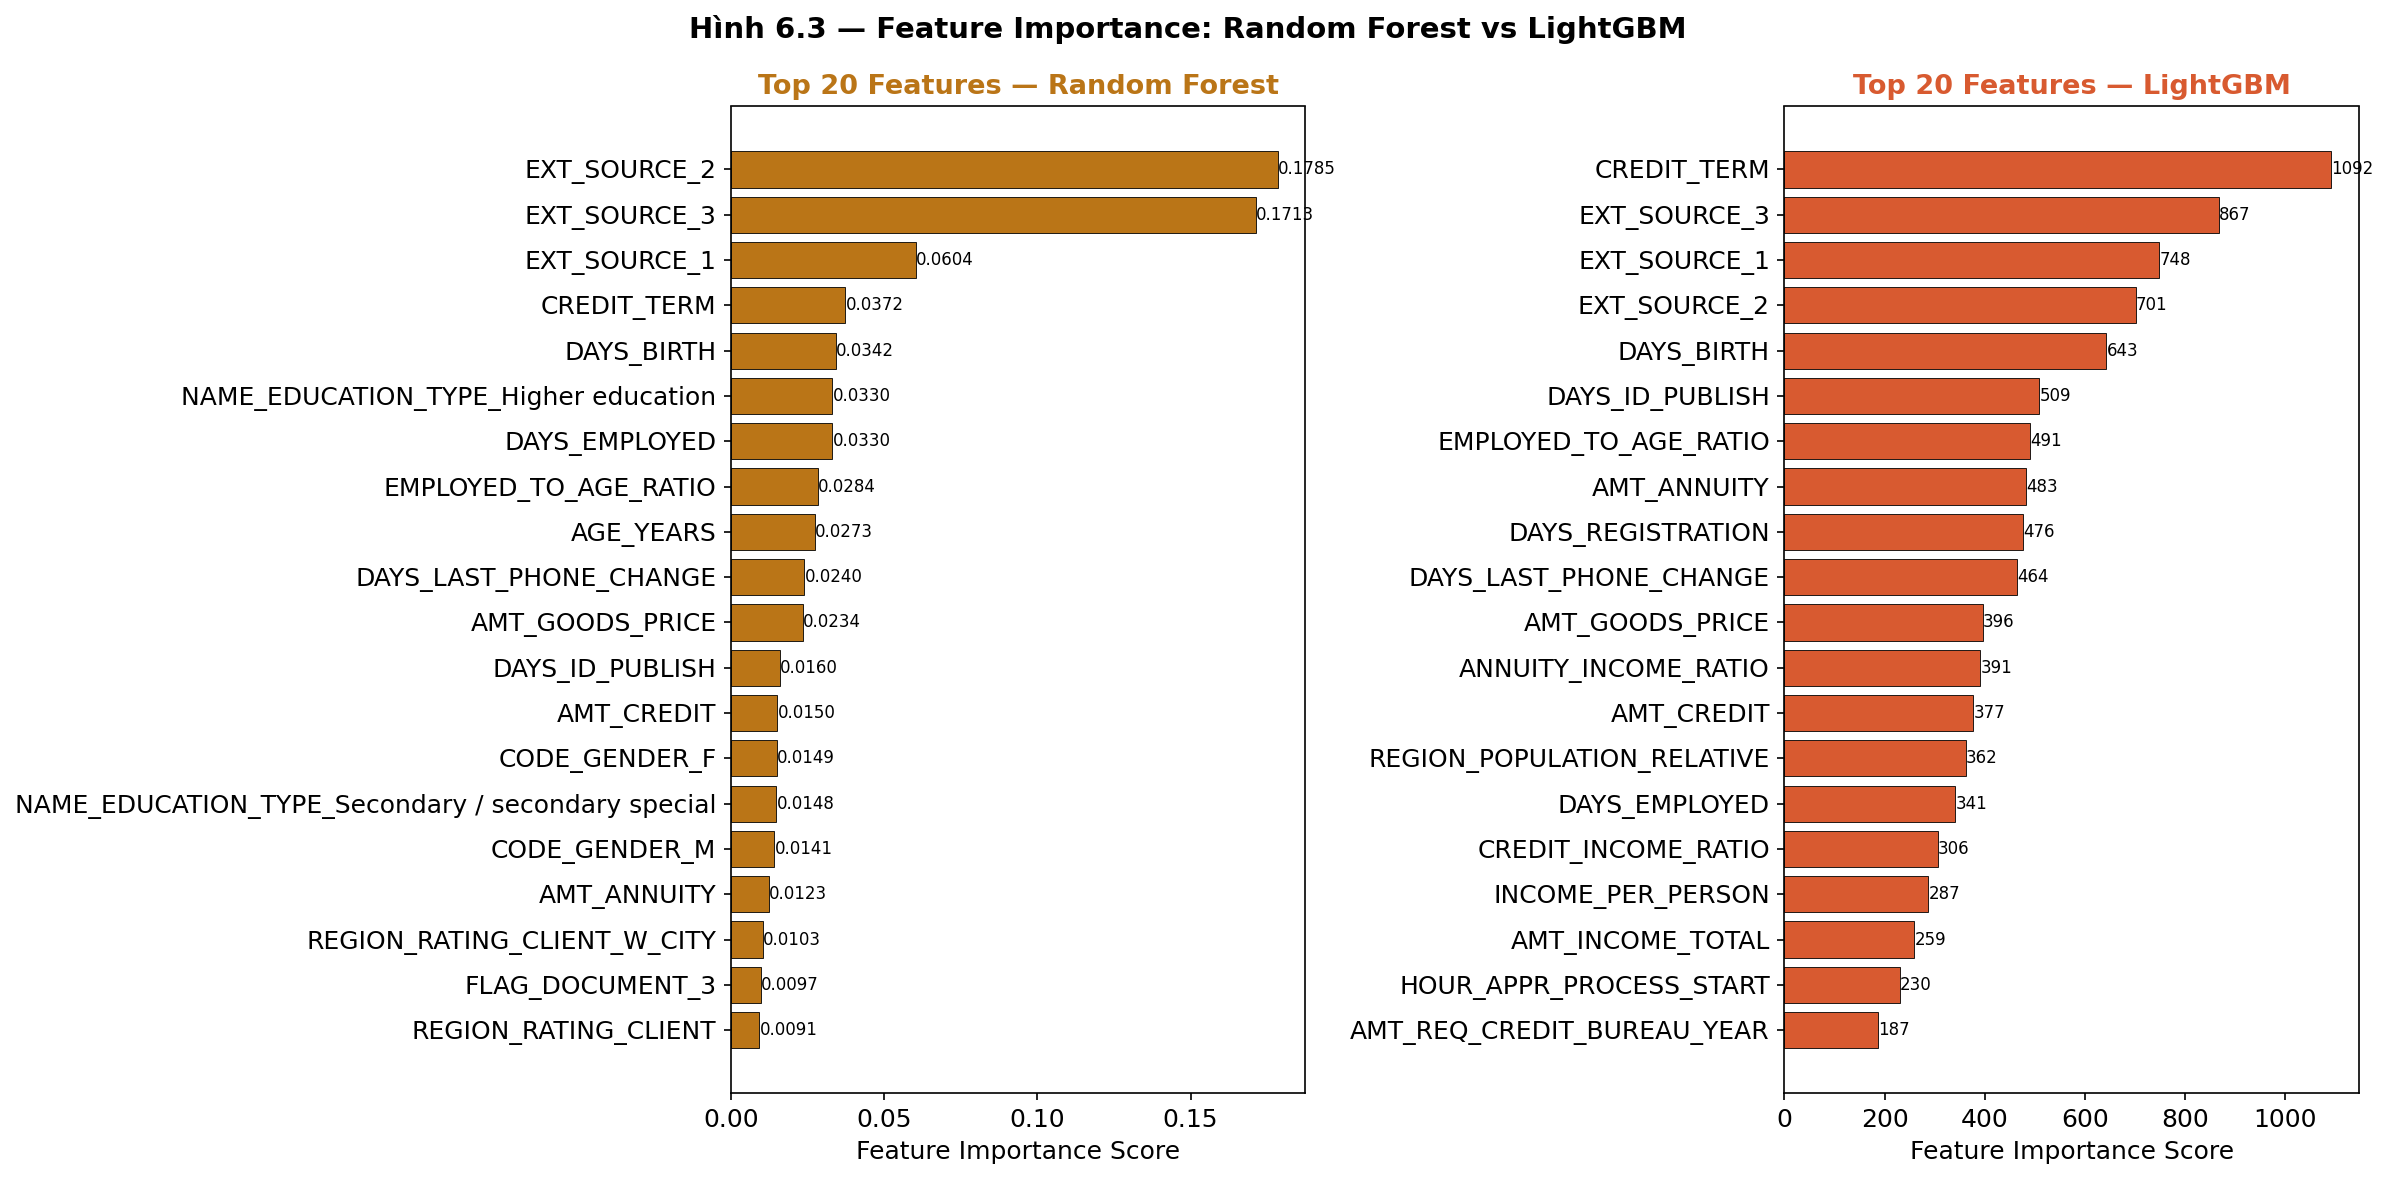

Đã lưu: H6.3_feature_importance.png


In [22]:
## PHẦN 6 — FEATURE IMPORTANCE

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# TOP 20 features — Random Forest
rf_model = trained_models['Random Forest']
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

axes[0].barh(rf_importance.index, rf_importance.values,
             color='#BA7517', edgecolor='black', linewidth=0.4)
axes[0].set_title('Top 20 Features — Random Forest',
                  fontsize=13, fontweight='bold', color='#BA7517')
axes[0].set_xlabel('Feature Importance Score')
for i, v in enumerate(rf_importance.values):
    axes[0].text(v + 0.0001, i, f'{v:.4f}',
                 va='center', fontsize=8)

# TOP 20 features — LightGBM
lgbm_model = trained_models['LightGBM']
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train_lgbm.columns
).sort_values(ascending=True).tail(20)

axes[1].barh(lgbm_importance.index, lgbm_importance.values,
             color='#D85A30', edgecolor='black', linewidth=0.4)
axes[1].set_title('Top 20 Features — LightGBM',
                  fontsize=13, fontweight='bold', color='#D85A30')
axes[1].set_xlabel('Feature Importance Score')
for i, v in enumerate(lgbm_importance.values):
    axes[1].text(v + 0.5, i, f'{v:.0f}',
                 va='center', fontsize=8)

fig.suptitle('Hình 6.3 — Feature Importance: Random Forest vs LightGBM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + 'H6.3_feature_importance.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Đã lưu: H6.3_feature_importance.png")

CHÊNH LỆCH TRAIN AUC vs VALIDATION AUC
Logistic Regression       Train=0.7499  Val=0.7519  Diff=-0.0021  ✅ Ổn định
Decision Tree             Train=0.7470  Val=0.7153  Diff=0.0317  ⚠️ Overfit
Random Forest             Train=0.7650  Val=0.7387  Diff=0.0263  ⚠️ Overfit
LightGBM                  Train=0.8492  Val=0.7658  Diff=0.0834  ⚠️ Overfit


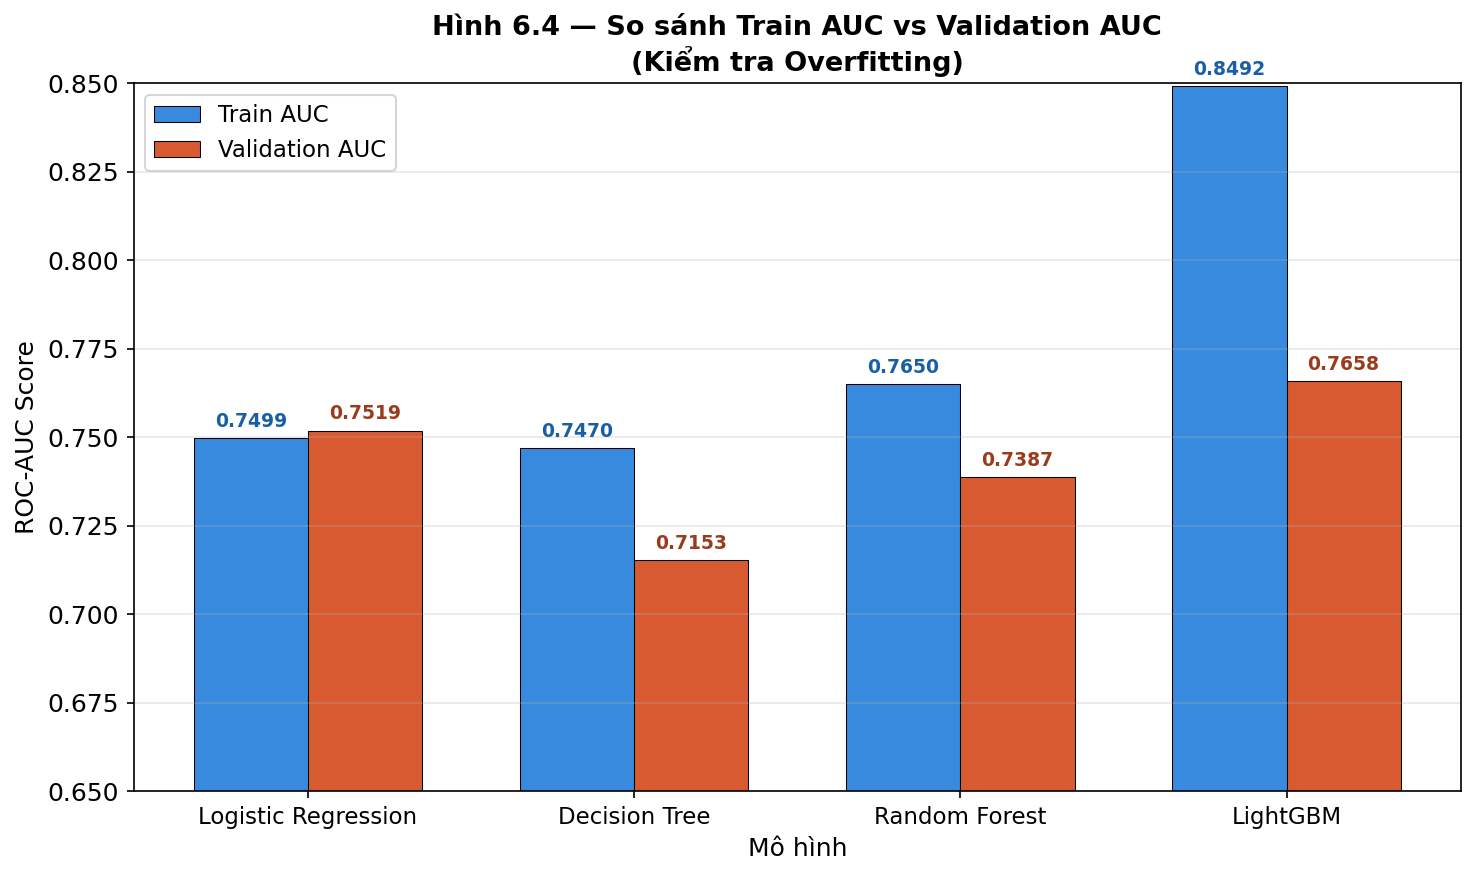


Đã lưu: H6.4_train_vs_val.png


In [23]:
## PHẦN 6 — TRAIN VS VALIDATION (OVERFITTING CHECK)

from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

train_aucs = {}
val_aucs   = {}

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        train_proba = model.predict_proba(X_train_scaled)[:, 1]
        val_proba   = model.predict_proba(X_val_scaled)[:, 1]
    elif name == 'LightGBM':
        train_proba = model.predict_proba(X_train_lgbm)[:, 1]
        val_proba   = model.predict_proba(X_val_lgbm)[:, 1]
    else:
        train_proba = model.predict_proba(X_train)[:, 1]
        val_proba   = model.predict_proba(X_val)[:, 1]

    train_aucs[name] = roc_auc_score(y_train, train_proba)
    val_aucs[name]   = roc_auc_score(y_val, val_proba)

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

names  = list(train_aucs.keys())
x      = np.arange(len(names))
width  = 0.35

bars1 = ax.bar(x - width/2, [train_aucs[n] for n in names],
               width, label='Train AUC',
               color='#378ADD', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, [val_aucs[n] for n in names],
               width, label='Validation AUC',
               color='#D85A30', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Mô hình', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Hình 6.4 — So sánh Train AUC vs Validation AUC\n(Kiểm tra Overfitting)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0.65, 0.85])
ax.grid(axis='y', alpha=0.3)

# Nhãn trên từng bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#185FA5')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#993C1D')

# Chênh lệch
print("=" * 55)
print("CHÊNH LỆCH TRAIN AUC vs VALIDATION AUC")
print("=" * 55)
for name in names:
    diff = train_aucs[name] - val_aucs[name]
    status = "⚠️ Overfit" if diff > 0.02 else "✅ Ổn định"
    print(f"{name:<25} Train={train_aucs[name]:.4f}  "
          f"Val={val_aucs[name]:.4f}  "
          f"Diff={diff:.4f}  {status}")

plt.tight_layout()
plt.savefig(save_path + 'H6.4_train_vs_val.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("\nĐã lưu: H6.4_train_vs_val.png")

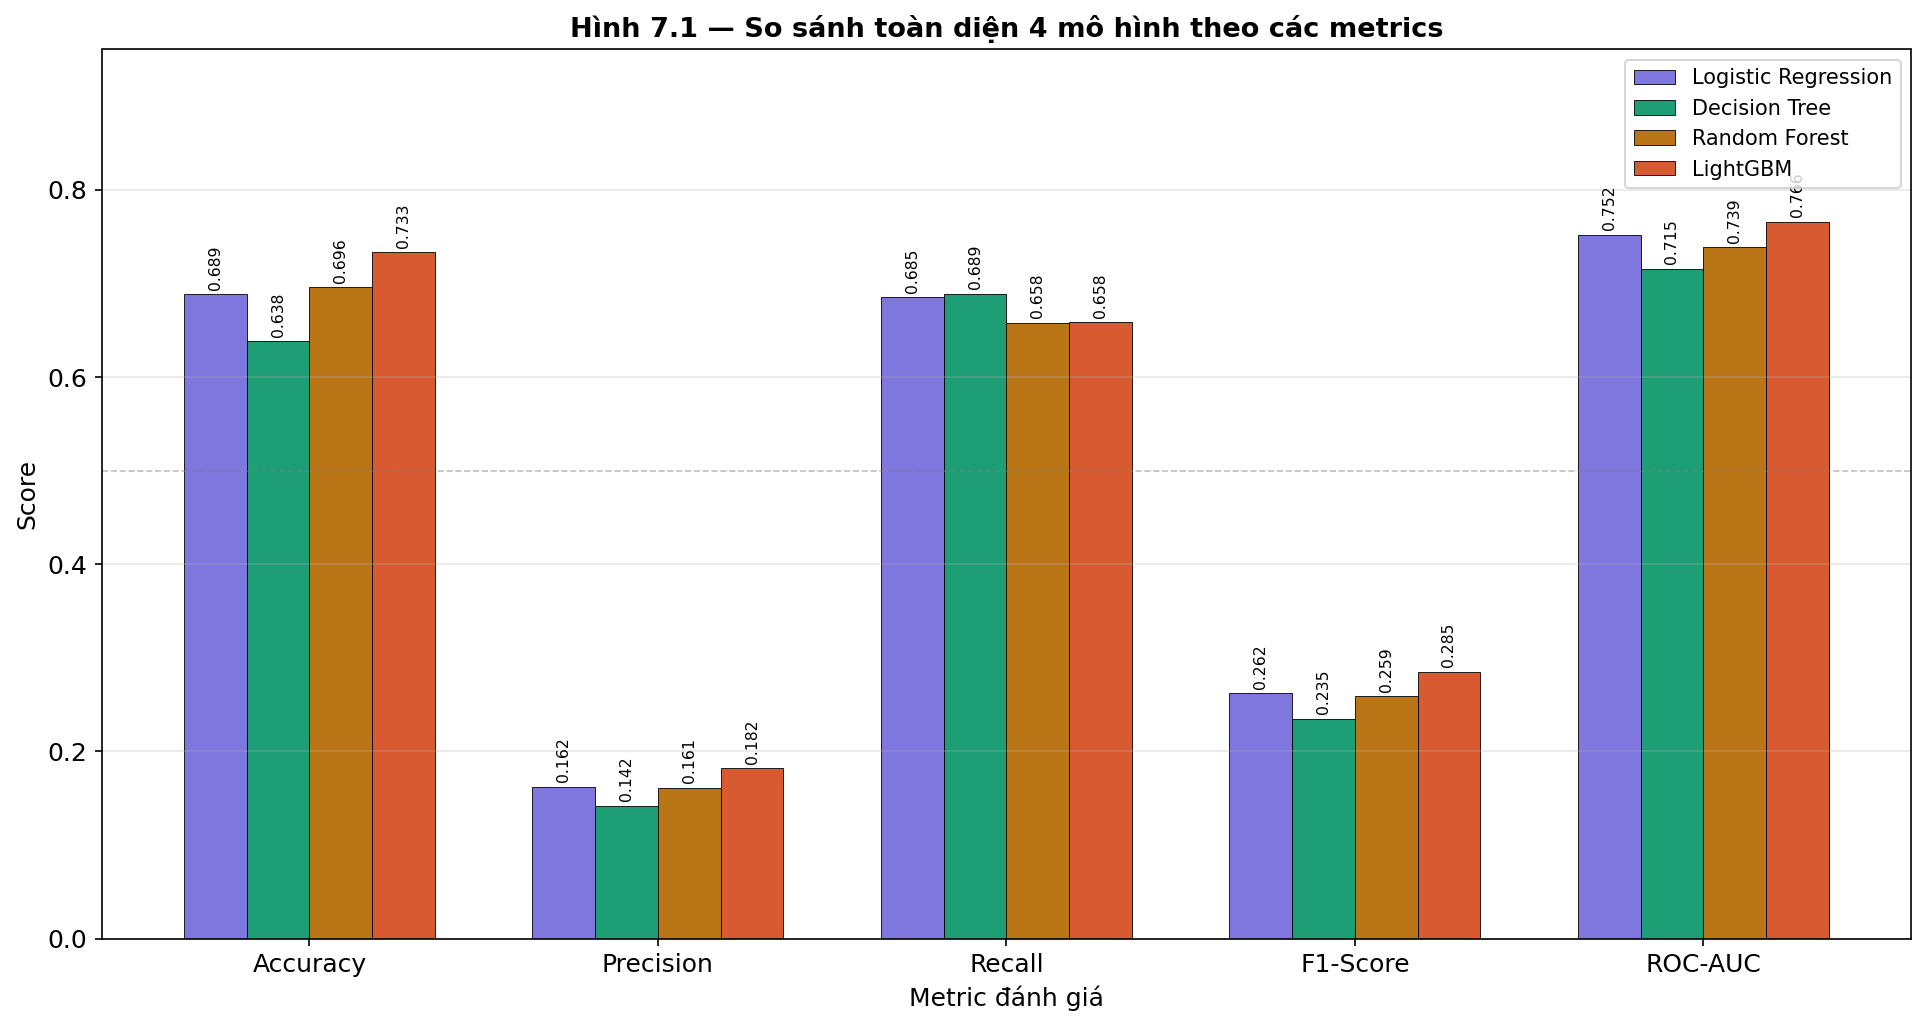

Đã lưu: H7.1_so_sanh_mo_hinh.png


In [24]:
## PHẦN 7 — BIỂU ĐỒ SO SÁNH 4 MÔ HÌNH

import matplotlib.pyplot as plt
import numpy as np

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors    = ['#7F77DD', '#1D9E75', '#BA7517', '#D85A30']
bar_width = 0.18
x         = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(13, 7))

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=name, color=color,
                  edgecolor='black', linewidth=0.4)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom',
                fontsize=7.5, rotation=90)

ax.set_xlabel('Metric đánh giá', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Hình 7.1 — So sánh toàn diện 4 mô hình theo các metrics',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim([0, 0.95])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.5, label='Ngưỡng 0.5')

plt.tight_layout()
plt.savefig(save_path + 'H7.1_so_sanh_mo_hinh.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Đã lưu: H7.1_so_sanh_mo_hinh.png")